# HW08 (Домашнее задание к семинару S08) – Нейронные сети (PyTorch)

## MLP и методы борьбы с переобучением: Dropout, BatchNorm, EarlyStopping

В рамках домашнего задания я реализую базовую полносвязную нейронную сеть (MLP) на выбранном датасете из `torchvision` и проведу серию экспериментов по исследованию переобучения и способов его уменьшения.

Цель работы — не просто обучить модель, а сравнить несколько архитектурных и регуляризационных решений и на основе метрик validation выбрать лучшую конфигурацию.

В ходе выполнения задания я:

* реализую MLP (полносвязную нейронную сеть) с использованием `torch.nn.Module`;
* напишу корректный цикл обучения с разделением режимов `train()` и `eval()`, использованием `torch.no_grad()` и переносом данных и модели на выбранное устройство (`cpu` или `cuda`);
* выполню воспроизводимое разбиение train/val;
* проведу серию экспериментов (E0–E4), сравнив:

  * базовую модель,
  * более сложную архитектуру,
  * модель с Dropout,
  * модель с BatchNorm,
  * лучшую модель с EarlyStopping;
* проанализирую влияние регуляризации на качество обобщения;
* выберу лучшую модель по `val_accuracy` и выполню финальную оценку на test-выборке.

Дополнительно в работе фиксируется `seed` для воспроизводимости результатов.


# Импорты и общие настройки

Сразу сделаем две инженерные привычки:
1) фиксируем seed (воспроизводимость),
2) явно выбираем `device` (CPU/GPU).

In [1]:
# ============================================
# 1. Импорты и общие настройки
# ============================================

# Базовые библиотеки
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

# ============================================
# 1.1 Фиксация seed для воспроизводимости
# ============================================

def set_seed(seed: int = 42) -> None:
    """
    Фиксируем seed для воспроизводимости результатов.
    Важно для корректного сравнения экспериментов.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ============================================
# 1.2 Определение устройства (CPU/GPU)
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
device: cpu


# Создание структуры папок для HW08

In [2]:
# ============================================
# 2. Создание структуры папок для HW08
# ============================================

HW08_DIR = Path("./homeworks/HW08")
ARTIFACTS_DIR = HW08_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

# for dir_path in [HW08_DIR, ARTIFACTS_DIR, FIGURES_DIR]:
for dir_path in [ARTIFACTS_DIR, FIGURES_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)
    print(f"Создана папка: {dir_path}")

Создана папка: homeworks/HW08
Создана папка: homeworks/HW08/artifacts
Создана папка: homeworks/HW08/artifacts/figures


# Вспомогательные функции (метрики и графики)

In [3]:
# ============================================
# 3. Вспомогательные функции (метрики и графики)
# ============================================

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    """
    Вычисление accuracy для классификации:
    logits -> argmax -> сравнение с y_true
    """
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def plot_history(history: dict, title: str = "") -> None:
    """
    Построение графиков обучения:
    - loss (train/val)
    - accuracy (train/val)
    """
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    # График потерь
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss", marker='o')
    plt.plot(epochs, history["val_loss"], label="val_loss", marker='s')
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)

    # График точности
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc", marker='o')
    plt.plot(epochs, history["val_acc"], label="val_acc", marker='s')
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Выбор датасета

В данной работе используется датасет **EMNIST (Extended MNIST), split="balanced"** — расширенная версия MNIST, содержащая рукописные цифры и буквы латинского алфавита.

Особенности выбранного варианта:

* 47 классов (цифры + буквы),
* изображения размером 28×28 пикселей,
* 1 канал (grayscale),
* формат полностью совместим с MNIST.

По сравнению с MNIST, задача является более сложной, поскольку:

* классов больше,
* визуальные различия между некоторыми символами минимальны,
* это делает регуляризацию более значимой.

Поскольку используется MLP (а не CNN):

* изображения размером 28×28 преобразуются в вектор размерности 784 признака через `Flatten` внутри модели.

Дополнительно:

* используется `ToTensor()` для перевода изображений в тензоры PyTorch,
* применяется нормализация `(mean=0.5, std=0.5)` для стабилизации обучения.

---

In [4]:
DATASET_CHOICE = "EMNIST"
dataset_class = torchvision.datasets.EMNIST
# split="balanced" даёт 47 классов, split="letters" - 26 классов
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
input_dim = 28 * 28  # 784
num_classes = 47  # для balanced split
dataset_params = {"split": "balanced"}  # ОБЯЗАТЕЛЬНО указываем split для EMNIST


# Загрузка данных и создание DataLoader

100%|██████████| 562M/562M [00:02<00:00, 235MB/s]


Размер обучающей выборки: 112800
Размер тестовой выборки: 18800
После разбиения: train=90240, val=22560

Sanity-check:
x_batch: shape=torch.Size([64, 1, 28, 28]), dtype=torch.float32
y_batch: shape=torch.Size([64]), dtype=torch.int64
Диапазон значений x: [-1.000, 1.000]

Примеры изображений из датасета:


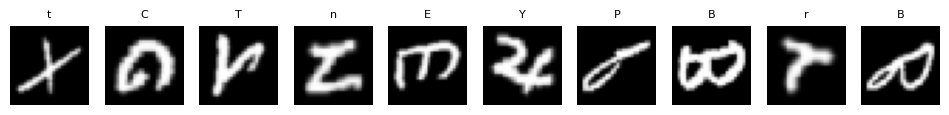

In [5]:
# Скачиваем датасет
train_full = dataset_class(
    root="./data", train=True, download=True, transform=transform, **dataset_params
)
test_ds = dataset_class(
    root="./data", train=False, download=True, transform=transform, **dataset_params
)

# Получаем названия классов (если есть)
if hasattr(train_full, 'classes'):
    class_names = train_full.classes
else:
    class_names = [str(i) for i in range(num_classes)]

print(f"Размер обучающей выборки: {len(train_full)}")
print(f"Размер тестовой выборки: {len(test_ds)}")

# ============================================
# 5.1 Разбиение train/val (80/20) с фиксированным seed
# ============================================

val_ratio = 0.2  # 20% на валидацию
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

# Используем Generator с фиксированным seed для воспроизводимости
gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

print(f"После разбиения: train={len(train_ds)}, val={len(val_ds)}")

# ============================================
# 5.2 Создание DataLoader
# ============================================

# Настройка batch_size в зависимости от наличия GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# Для Windows в Jupyter иногда проблемы с multiprocessing
NUM_WORKERS = 0 if os.name == "nt" else 2

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# ============================================
# 5.3 Sanity-check: проверка загрузки данных
# ============================================

x_batch, y_batch = next(iter(train_loader))
print("\nSanity-check:")
print(f"x_batch: shape={x_batch.shape}, dtype={x_batch.dtype}")
print(f"y_batch: shape={y_batch.shape}, dtype={y_batch.dtype}")
print(f"Диапазон значений x: [{x_batch.min():.3f}, {x_batch.max():.3f}]")

# ============================================
# 5.4 Визуализация примеров из датасета
# ============================================

def show_images(loader, n: int = 10) -> None:
    """Показывает первые n изображений из батча"""
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)

        # Для RGB изображений (CIFAR10)
        if x.shape[1] == 3:
            img = x[i].permute(1, 2, 0).numpy()
            img = img * 0.5 + 0.5  # денормализация
            img = np.clip(img, 0, 1)
            plt.imshow(img)
        else:  # Для grayscale (KMNIST, EMNIST)
            img = x[i].squeeze().numpy()
            img = img * 0.5 + 0.5  # денормализация
            plt.imshow(img, cmap="gray")

        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

print("\nПримеры изображений из датасета:")
show_images(train_loader, n=10)

# Определение модели MLP

In [6]:
# ============================================
# 6. Определение модели MLP
# ============================================

class MLP(nn.Module):
    """
    Многослойный перцептрон с поддержкой:
    - Dropout
    - BatchNorm
    - различных функций активации
    """
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        # Выбор функции активации
        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        # Сборка слоёв
        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))

            layers.append(act_layer())

            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))

            prev = h

        # Выходной слой (без активации - для CrossEntropyLoss)
        layers.append(nn.Linear(prev, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Проверка формы выходных данных
test_model = MLP(input_dim=input_dim, num_classes=num_classes).to(device)
with torch.no_grad():
    test_out = test_model(x_batch.to(device))
print(f"\nПроверка модели: logits shape = {test_out.shape}")


Проверка модели: logits shape = torch.Size([64, 47])


# Метрики и train/eval функции

In [7]:
# ============================================
# 7. Функции для обучения и оценки
# ============================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Одна эпоха обучения:
    - model.train() включает Dropout/BatchNorm
    - проход по всем батчам
    - обновление весов
    """
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Обнуление градиентов
        optimizer.zero_grad(set_to_none=True)

        # Прямой проход
        logits = model(x)
        loss = criterion(logits, y)

        # Обратный проход
        loss.backward()
        optimizer.step()

        # Сбор статистики
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Оценка модели на валидации/тесте:
    - model.eval() выключает Dropout и фиксирует BatchNorm
    - torch.no_grad() отключает вычисление градиентов
    """
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

# EarlyStopping

In [8]:
# ============================================
# 8. Early Stopping (ранняя остановка)
# ============================================

class EarlyStopping:
    """
    Ранняя остановка обучения:
    - отслеживает метрику на валидации
    - сохраняет лучшие веса
    - останавливает обучение при отсутствии улучшений
    """
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        """
        Делает шаг early stopping.
        score: метрика (чем больше, тем лучше, например val_acc)
        return: True если нужно остановиться
        """
        if self.best_score is None:
            # Первая эпоха
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            # Улучшение
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        else:
            # Нет улучшения
            self.counter += 1
            return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        """Восстанавливает лучшие веса модели"""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


# Функция fit для обучения экспериментов

In [9]:
# ============================================
# 9. Основная функция обучения
# ============================================

def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    """
    Полный цикл обучения модели
    """
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        # Обучение
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

        # Валидация
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        # Сохранение истории
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        # Проверка early stopping
        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

# Функции для работы с артефактами

In [10]:
# ============================================
# 10. Функции для работы с артефактами
# ============================================

def get_model_config(model, experiment_id, dataset_name, seed, epochs_trained):
    """
    Создаёт конфиг модели для сохранения в JSON
    """
    # Пытаемся определить параметры из модели
    dropout_p = 0.0
    use_batchnorm = False
    hidden_dims = (256, 128)  # значение по умолчанию

    if hasattr(model, 'net'):
        # Проходим по слоям и ищем Dropout и BatchNorm
        for layer in model.net:
            if isinstance(layer, nn.Dropout):
                dropout_p = layer.p
            if isinstance(layer, nn.BatchNorm1d):
                use_batchnorm = True

        # Пытаемся определить размеры скрытых слоёв
        hidden_dims_list = []
        for layer in model.net:
            if isinstance(layer, nn.Linear):
                if layer.out_features != num_classes:  # не выходной слой
                    hidden_dims_list.append(layer.out_features)
        if hidden_dims_list:
            hidden_dims = hidden_dims_list

    config = {
        "experiment_id": experiment_id,
        "dataset": dataset_name,
        "seed": seed,
        "input_dim": input_dim,
        "hidden_dims": hidden_dims if isinstance(hidden_dims, list) else list(hidden_dims),
        "num_classes": num_classes,
        "dropout_p": dropout_p,
        "use_batchnorm": use_batchnorm,
        "activation": "relu",  # в нашей модели всегда ReLU
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "batch_size": BATCH_SIZE,
        "epochs_trained": epochs_trained
    }
    return config

def has_dropout(model):
    """Проверяет, есть ли в модели Dropout"""
    for layer in model.net:
        if isinstance(layer, nn.Dropout):
            return True
    return False

def has_batchnorm(model):
    """Проверяет, есть ли в модели BatchNorm"""
    for layer in model.net:
        if isinstance(layer, nn.BatchNorm1d):
            return True
    return False

# Проведение экспериментов E0-E4


Эксперимент E0: Baseline (1 скрытый слой, 128 нейронов)
epoch 01/20 | train loss=1.2950, acc=0.6336 | val loss=0.9649, acc=0.7175
epoch 02/20 | train loss=0.8366, acc=0.7484 | val loss=0.8042, acc=0.7514
epoch 03/20 | train loss=0.7067, acc=0.7799 | val loss=0.7072, acc=0.7818
epoch 04/20 | train loss=0.6377, acc=0.7974 | val loss=0.6676, acc=0.7932
epoch 05/20 | train loss=0.5975, acc=0.8068 | val loss=0.6359, acc=0.7984
epoch 06/20 | train loss=0.5716, acc=0.8138 | val loss=0.6367, acc=0.8039
epoch 07/20 | train loss=0.5505, acc=0.8191 | val loss=0.6232, acc=0.8072
epoch 08/20 | train loss=0.5346, acc=0.8238 | val loss=0.6092, acc=0.8089
epoch 09/20 | train loss=0.5207, acc=0.8271 | val loss=0.6493, acc=0.7990
epoch 10/20 | train loss=0.5082, acc=0.8302 | val loss=0.6159, acc=0.8075
epoch 11/20 | train loss=0.4958, acc=0.8330 | val loss=0.6038, acc=0.8152
epoch 12/20 | train loss=0.4868, acc=0.8356 | val loss=0.6046, acc=0.8113
epoch 13/20 | train loss=0.4799, acc=0.8380 | val loss=

/tmp/ipython-input-465307402.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)


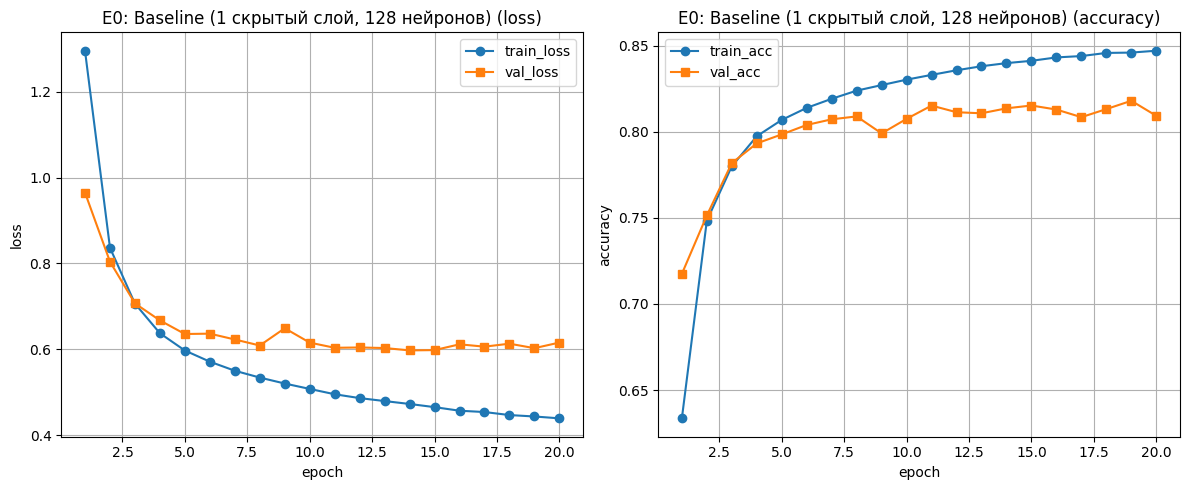


Эксперимент E1: Более глубокая сеть (2 слоя: 256, 128)
epoch 01/20 | train loss=1.1735, acc=0.6563 | val loss=0.7877, acc=0.7571
epoch 02/20 | train loss=0.6812, acc=0.7814 | val loss=0.6655, acc=0.7848
epoch 03/20 | train loss=0.5776, acc=0.8087 | val loss=0.6039, acc=0.8036
epoch 04/20 | train loss=0.5216, acc=0.8252 | val loss=0.5781, acc=0.8083
epoch 05/20 | train loss=0.4807, acc=0.8342 | val loss=0.5524, acc=0.8202
epoch 06/20 | train loss=0.4544, acc=0.8427 | val loss=0.5680, acc=0.8179
epoch 07/20 | train loss=0.4330, acc=0.8471 | val loss=0.5321, acc=0.8308
epoch 08/20 | train loss=0.4120, acc=0.8528 | val loss=0.5550, acc=0.8223
epoch 09/20 | train loss=0.3983, acc=0.8558 | val loss=0.5409, acc=0.8288
epoch 10/20 | train loss=0.3813, acc=0.8604 | val loss=0.5429, acc=0.8297
epoch 11/20 | train loss=0.3698, acc=0.8638 | val loss=0.5294, acc=0.8351
epoch 12/20 | train loss=0.3597, acc=0.8660 | val loss=0.5385, acc=0.8321
epoch 13/20 | train loss=0.3502, acc=0.8685 | val loss=0

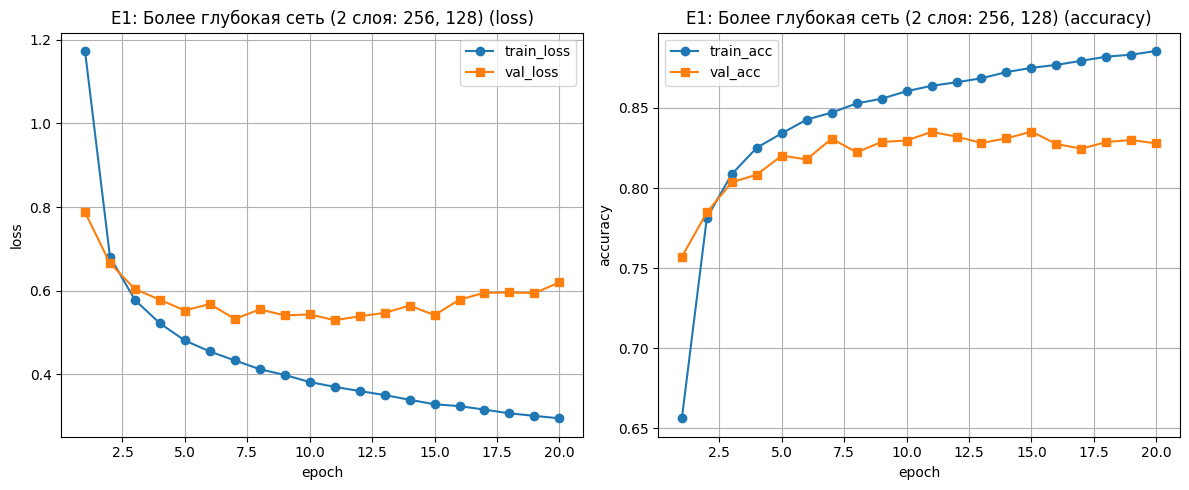


Эксперимент E2: E1 + Dropout(0.3)
epoch 01/20 | train loss=1.5670, acc=0.5414 | val loss=0.8836, acc=0.7257
epoch 02/20 | train loss=1.0723, acc=0.6710 | val loss=0.7369, acc=0.7700
epoch 03/20 | train loss=0.9617, acc=0.6991 | val loss=0.6882, acc=0.7794
epoch 04/20 | train loss=0.9076, acc=0.7130 | val loss=0.6499, acc=0.7890
epoch 05/20 | train loss=0.8712, acc=0.7230 | val loss=0.6256, acc=0.7962
epoch 06/20 | train loss=0.8540, acc=0.7268 | val loss=0.6091, acc=0.8048
epoch 07/20 | train loss=0.8325, acc=0.7344 | val loss=0.6039, acc=0.8036
epoch 08/20 | train loss=0.8169, acc=0.7387 | val loss=0.6015, acc=0.8002
epoch 09/20 | train loss=0.8064, acc=0.7404 | val loss=0.5805, acc=0.8086
epoch 10/20 | train loss=0.7897, acc=0.7442 | val loss=0.5649, acc=0.8110
epoch 11/20 | train loss=0.7845, acc=0.7446 | val loss=0.5716, acc=0.8116
epoch 12/20 | train loss=0.7811, acc=0.7482 | val loss=0.5725, acc=0.8109
epoch 13/20 | train loss=0.7717, acc=0.7489 | val loss=0.5666, acc=0.8118
epo

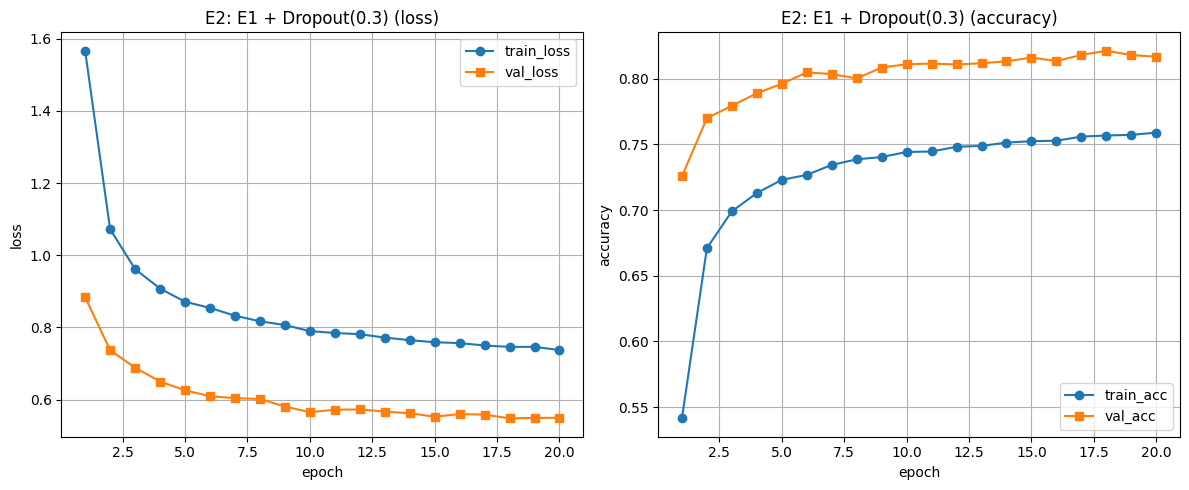


Эксперимент E3: E1 + BatchNorm
epoch 01/20 | train loss=0.9189, acc=0.7372 | val loss=0.5819, acc=0.8138
epoch 02/20 | train loss=0.5367, acc=0.8212 | val loss=0.5219, acc=0.8238
epoch 03/20 | train loss=0.4638, acc=0.8410 | val loss=0.4932, acc=0.8325
epoch 04/20 | train loss=0.4205, acc=0.8515 | val loss=0.4780, acc=0.8390
epoch 05/20 | train loss=0.3906, acc=0.8603 | val loss=0.4560, acc=0.8477
epoch 06/20 | train loss=0.3650, acc=0.8678 | val loss=0.4565, acc=0.8488
epoch 07/20 | train loss=0.3467, acc=0.8723 | val loss=0.4557, acc=0.8505
epoch 08/20 | train loss=0.3271, acc=0.8781 | val loss=0.4584, acc=0.8472
epoch 09/20 | train loss=0.3122, acc=0.8828 | val loss=0.4591, acc=0.8510
epoch 10/20 | train loss=0.2972, acc=0.8879 | val loss=0.4655, acc=0.8509
epoch 11/20 | train loss=0.2866, acc=0.8896 | val loss=0.4682, acc=0.8510
epoch 12/20 | train loss=0.2758, acc=0.8931 | val loss=0.4723, acc=0.8507
epoch 13/20 | train loss=0.2676, acc=0.8950 | val loss=0.4768, acc=0.8488
epoch 

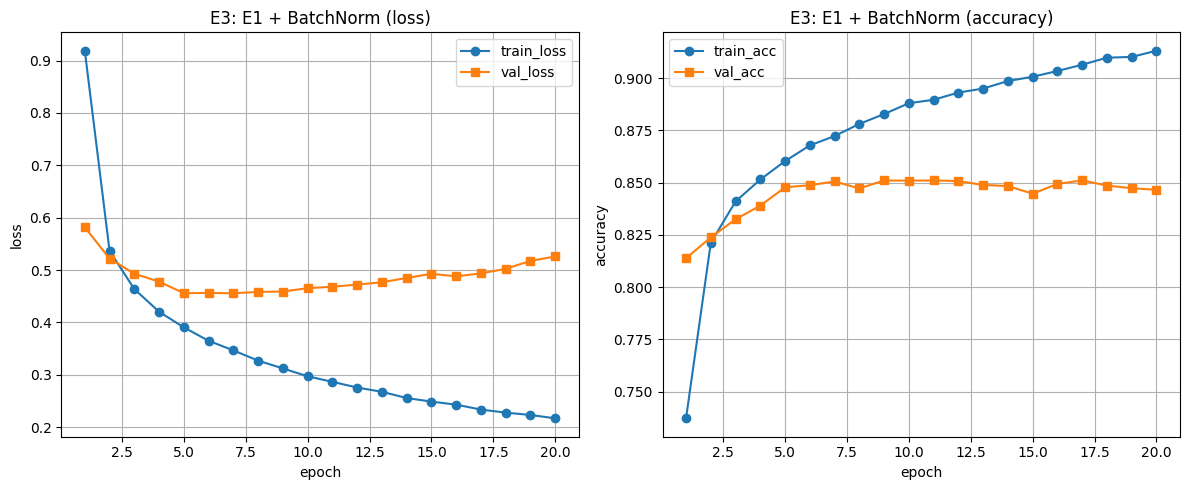


Лучший E3 (0.8511) > E2 (0.8214)

Эксперимент E4: Лучший из E2/E3 (E3 + EarlyStopping)
epoch 01/50 | train loss=0.9189, acc=0.7372 | val loss=0.5819, acc=0.8138
epoch 02/50 | train loss=0.5367, acc=0.8212 | val loss=0.5219, acc=0.8238
epoch 03/50 | train loss=0.4638, acc=0.8410 | val loss=0.4932, acc=0.8325
epoch 04/50 | train loss=0.4205, acc=0.8515 | val loss=0.4780, acc=0.8390
epoch 05/50 | train loss=0.3906, acc=0.8603 | val loss=0.4560, acc=0.8477
epoch 06/50 | train loss=0.3650, acc=0.8678 | val loss=0.4565, acc=0.8488
epoch 07/50 | train loss=0.3467, acc=0.8723 | val loss=0.4557, acc=0.8505
epoch 08/50 | train loss=0.3271, acc=0.8781 | val loss=0.4584, acc=0.8472
epoch 09/50 | train loss=0.3122, acc=0.8828 | val loss=0.4591, acc=0.8510
epoch 10/50 | train loss=0.2972, acc=0.8879 | val loss=0.4655, acc=0.8509
epoch 11/50 | train loss=0.2866, acc=0.8896 | val loss=0.4682, acc=0.8510
epoch 12/50 | train loss=0.2758, acc=0.8931 | val loss=0.4723, acc=0.8507
epoch 13/50 | train loss

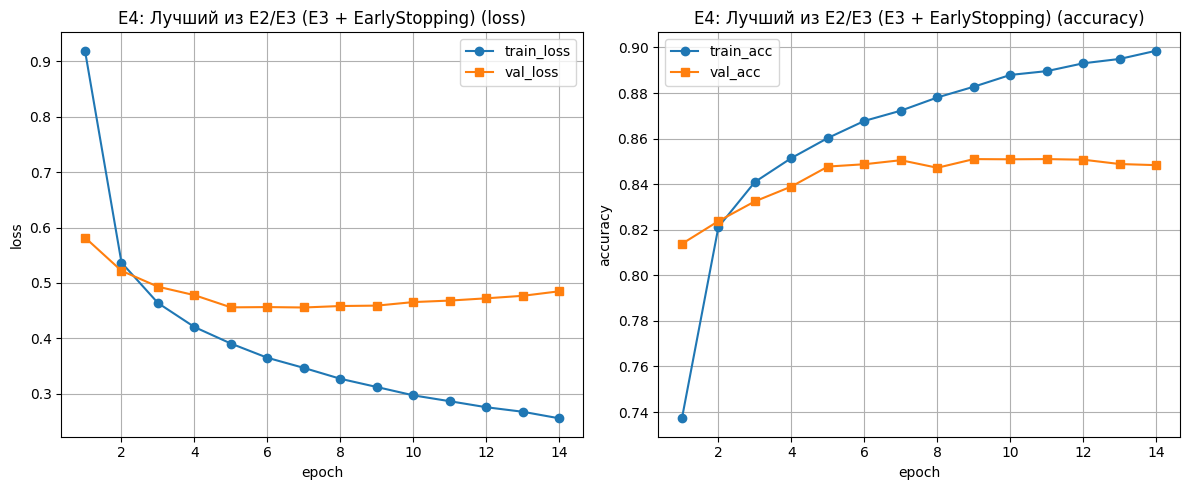

In [21]:
# ============================================
# 11. Проведение экспериментов E0-E4
# ============================================

# Таблица для результатов
results_df = pd.DataFrame(columns=[
    "experiment_id", "dataset", "seed", "model_summary",
    "dropout", "batchnorm", "epochs_trained",
    "best_val_accuracy", "best_val_loss", "best_epoch"
])

def run_experiment(experiment_id, model, train_loader, val_loader,
                   criterion, optimizer, device, epochs=20,
                   early_stopping=None, description=""):
    """
    Проводит один эксперимент и сохраняет результаты
    """
    print(f"\n{'='*60}")
    print(f"Эксперимент {experiment_id}: {description}")
    print(f"{'='*60}")

    set_seed(42)  # фиксируем seed для воспроизводимости

    # Обучение
    history = fit(
        model, train_loader, val_loader,
        optimizer, criterion, device,
        epochs=epochs,
        early_stopping=early_stopping,
        verbose=True
    )

    # Поиск лучшей эпохи
    best_epoch = np.argmax(history["val_acc"])
    best_val_acc = history["val_acc"][best_epoch]
    best_val_loss = history["val_loss"][best_epoch]
    epochs_trained = len(history["train_loss"])

    print(f"\nЛучший результат: эпоха {best_epoch+1}, "
          f"val_acc={best_val_acc:.4f}, val_loss={best_val_loss:.4f}")

    # Сохранение в таблицу
    global results_df
    new_row = {
        "experiment_id": experiment_id,
        "dataset": DATASET_CHOICE,
        "seed": 42,
        "model_summary": description,
        "dropout": has_dropout(model),
        "batchnorm": has_batchnorm(model),
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch": int(best_epoch + 1)
    }
    results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)

    # Построение графиков
    plot_history(history, title=f"{experiment_id}: {description}")

    return history, model, (best_val_acc, best_epoch)

# Словарь для хранения лучших моделей и их историй
best_models = {}
histories = {}

# ============================================
# 11.1 E0: Baseline (1 скрытый слой)
# ============================================

set_seed(42)
model_e0 = MLP(
    input_dim=input_dim,
    hidden_dims=(128,),  # один скрытый слой
    num_classes=num_classes,
    dropout_p=0.0,
    use_batchnorm=False
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e0.parameters(), lr=1e-3)

history_e0, _, best_info = run_experiment(
    "E0", model_e0, train_loader, val_loader,
    criterion, optimizer, device,
    epochs=20,
    description="Baseline (1 скрытый слой, 128 нейронов)"
)
best_models["E0"] = model_e0
histories["E0"] = history_e0

# ============================================
# 11.2 E1: Глубже/шире (2 скрытых слоя)
# ============================================

set_seed(42)
model_e1 = MLP(
    input_dim=input_dim,
    hidden_dims=(256, 128),  # два скрытых слоя
    num_classes=num_classes,
    dropout_p=0.0,
    use_batchnorm=False
).to(device)

optimizer = optim.Adam(model_e1.parameters(), lr=1e-3)

history_e1, _, best_info = run_experiment(
    "E1", model_e1, train_loader, val_loader,
    criterion, optimizer, device,
    epochs=20,
    description="Более глубокая сеть (2 слоя: 256, 128)"
)
best_models["E1"] = model_e1
histories["E1"] = history_e1

# ============================================
# 11.3 E2: E1 + Dropout
# ============================================

set_seed(42)
model_e2 = MLP(
    input_dim=input_dim,
    hidden_dims=(256, 128),
    num_classes=num_classes,
    dropout_p=0.3,  # dropout 30%
    use_batchnorm=False
).to(device)

optimizer = optim.Adam(model_e2.parameters(), lr=1e-3)

history_e2, _, best_info = run_experiment(
    "E2", model_e2, train_loader, val_loader,
    criterion, optimizer, device,
    epochs=20,
    description="E1 + Dropout(0.3)"
)
best_models["E2"] = model_e2
histories["E2"] = history_e2

# ============================================
# 11.4 E3: E1 + BatchNorm
# ============================================

set_seed(42)
model_e3 = MLP(
    input_dim=input_dim,
    hidden_dims=(256, 128),
    num_classes=num_classes,
    dropout_p=0.0,
    use_batchnorm=True  # BatchNorm включён
).to(device)

optimizer = optim.Adam(model_e3.parameters(), lr=1e-3)

history_e3, _, best_info = run_experiment(
    "E3", model_e3, train_loader, val_loader,
    criterion, optimizer, device,
    epochs=20,
    description="E1 + BatchNorm"
)
best_models["E3"] = model_e3
histories["E3"] = history_e3

# ============================================
# 11.5 E4: Лучший из E2/E3 + EarlyStopping
# ============================================

# Выбираем лучший по val_accuracy из E2 и E3
e2_best = results_df[results_df["experiment_id"] == "E2"]["best_val_accuracy"].values[0]
e3_best = results_df[results_df["experiment_id"] == "E3"]["best_val_accuracy"].values[0]

if e2_best > e3_best:
    print(f"\nЛучший E2 ({e2_best:.4f}) > E3 ({e3_best:.4f})")
    base_model_config = "E2 + EarlyStopping"
    use_dropout = 0.3
    use_bn = False
else:
    print(f"\nЛучший E3 ({e3_best:.4f}) > E2 ({e2_best:.4f})")
    base_model_config = "E3 + EarlyStopping"
    use_dropout = 0.0
    use_bn = True

set_seed(42)
model_e4 = MLP(
    input_dim=input_dim,
    hidden_dims=(256, 128),
    num_classes=num_classes,
    dropout_p=use_dropout,
    use_batchnorm=use_bn
).to(device)

optimizer = optim.Adam(model_e4.parameters(), lr=1e-3)
early_stopping = EarlyStopping(patience=5, min_delta=0.0002)  # patience в диапазоне 3-5

history_e4, _, best_info = run_experiment(
    "E4", model_e4, train_loader, val_loader,
    criterion, optimizer, device,
    epochs=50,  # больше эпох, но EarlyStopping остановит рано
    early_stopping=early_stopping,
    description=f"Лучший из E2/E3 ({base_model_config})"
)
best_models["E4"] = model_e4
histories["E4"] = history_e4

# Выбор лучшей модели

In [22]:
# ============================================
# 12. Выбор лучшей модели (с отображением и accuracy, и loss)
# ============================================

# Находим лучший эксперимент по val_accuracy
best_experiment_idx = results_df["best_val_accuracy"].idxmax()
best_experiment = results_df.loc[best_experiment_idx]

print(f"\n{'='*60}")
print(f"ЛУЧШАЯ МОДЕЛЬ:")
print(f"{'='*60}")
print(f"Эксперимент: {best_experiment['experiment_id']}")
print(f"Описание: {best_experiment['model_summary']}")
print(f"Лучшая валидационная точность: {best_experiment['best_val_accuracy']:.4f}")
print(f"Соответствующая валидационная потеря: {best_experiment['best_val_loss']:.4f}")
print(f"Достигнуто на эпохе: {best_experiment['best_epoch']}")

# Показываем также тестовые результаты для всех экспериментов
print(f"\n{'='*60}")
print(f"СРАВНЕНИЕ ВСЕХ ЭКСПЕРИМЕНТОВ:")
print(f"{'='*60}")
for idx, row in results_df.iterrows():
    print(f"{row['experiment_id']}: val_acc={row['best_val_accuracy']:.4f}, "
          f"val_loss={row['best_val_loss']:.4f}, "
          f"эпоха={row['best_epoch']}, "
          f"dropout={'да' if row['dropout'] else 'нет'}, "
          f"batchnorm={'да' if row['batchnorm'] else 'нет'}")

best_model_id = best_experiment["experiment_id"]
best_model = best_models[best_model_id]



ЛУЧШАЯ МОДЕЛЬ:
Эксперимент: E3
Описание: E1 + BatchNorm
Лучшая валидационная точность: 0.8511
Соответствующая валидационная потеря: 0.4937
Достигнуто на эпохе: 17

СРАВНЕНИЕ ВСЕХ ЭКСПЕРИМЕНТОВ:
E0: val_acc=0.8179, val_loss=0.6030, эпоха=19, dropout=нет, batchnorm=нет
E1: val_acc=0.8353, val_loss=0.5414, эпоха=15, dropout=нет, batchnorm=нет
E2: val_acc=0.8214, val_loss=0.5478, эпоха=18, dropout=да, batchnorm=нет
E3: val_acc=0.8511, val_loss=0.4937, эпоха=17, dropout=нет, batchnorm=да
E4: val_acc=0.8510, val_loss=0.4591, эпоха=9, dropout=нет, batchnorm=да


# Финальная оценка на тесте

In [23]:
# ============================================
# 13. Финальная оценка на тесте (с loss и accuracy)
# ============================================

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"\n{'='*60}")
print(f"ФИНАЛЬНАЯ ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ НА ТЕСТЕ:")
print(f"{'='*60}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"{'='*60}")

# Добавим также сравнение train/val/test для лучшей модели
print(f"\nСРАВНЕНИЕ ДЛЯ ЛУЧШЕЙ МОДЕЛИ ({best_experiment['experiment_id']}):")
print(f"Train accuracy (лучшая): {max(histories[best_model_id]['train_acc']):.4f}")
print(f"Val accuracy (лучшая): {best_experiment['best_val_accuracy']:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


ФИНАЛЬНАЯ ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ НА ТЕСТЕ:
Test loss: 0.5542
Test accuracy: 0.8427

СРАВНЕНИЕ ДЛЯ ЛУЧШЕЙ МОДЕЛИ (E3):
Train accuracy (лучшая): 0.9131
Val accuracy (лучшая): 0.8511
Test accuracy: 0.8427


# Сохранение артефактов


Сохранён homeworks/HW08/artifacts/runs.csv
Сохранена homeworks/HW08/artifacts/best_model.pt
Сохранён homeworks/HW08/artifacts/best_config.json


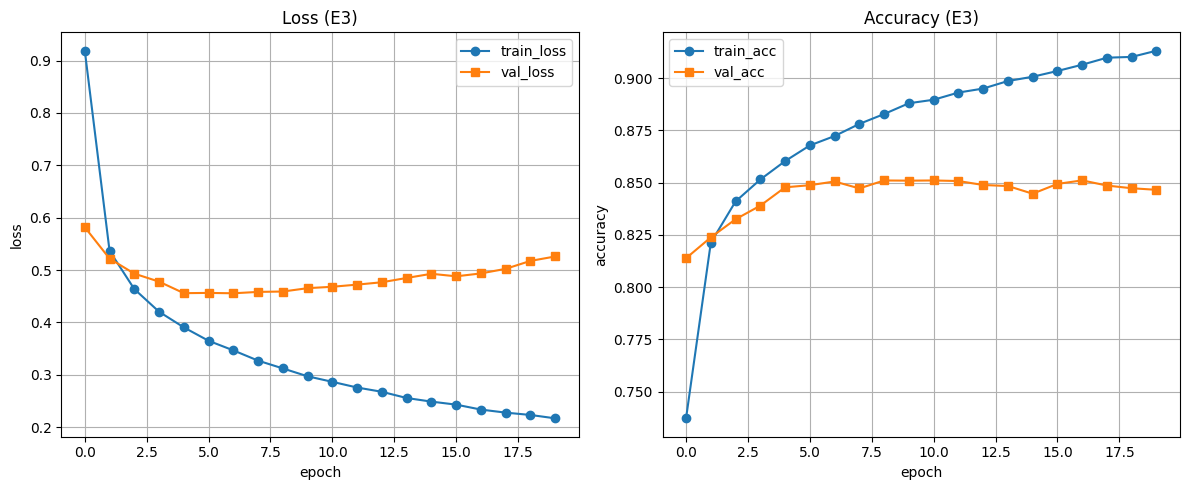

Сохранён график homeworks/HW08/artifacts/figures/curves_best.png


In [24]:
# ============================================
# 14. Сохранение артефактов
# ============================================

# 14.1 Сохраняем runs.csv
results_df.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
print(f"\nСохранён {ARTIFACTS_DIR}/runs.csv")

# 14.2 Сохраняем лучшую модель
torch.save(best_model.state_dict(), ARTIFACTS_DIR / "best_model.pt")
print(f"Сохранена {ARTIFACTS_DIR}/best_model.pt")

# 14.3 Сохраняем конфиг лучшей модели
best_config = get_model_config(
    best_model,
    best_experiment["experiment_id"],
    DATASET_CHOICE,
    42,
    int(best_experiment["epochs_trained"])
)

with open(ARTIFACTS_DIR / "best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=4, ensure_ascii=False)
print(f"Сохранён {ARTIFACTS_DIR}/best_config.json")

# 14.4 Сохраняем график для лучшей модели
best_history = histories[best_model_id]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(best_history["train_loss"], label="train_loss", marker='o')
plt.plot(best_history["val_loss"], label="val_loss", marker='s')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Loss ({best_experiment['experiment_id']})")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(best_history["train_acc"], label="train_acc", marker='o')
plt.plot(best_history["val_acc"], label="val_acc", marker='s')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title(f"Accuracy ({best_experiment['experiment_id']})")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "curves_best.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Сохранён график {FIGURES_DIR}/curves_best.png")

# Сводная таблица результатов

In [25]:
# ============================================
# 15. Сводная таблица результатов
# ============================================

print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ВСЕХ ЭКСПЕРИМЕНТОВ")
print("="*60)
print(results_df.to_string(index=False))


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ВСЕХ ЭКСПЕРИМЕНТОВ
experiment_id dataset seed                           model_summary dropout batchnorm epochs_trained  best_val_accuracy  best_val_loss best_epoch
           E0  EMNIST   42 Baseline (1 скрытый слой, 128 нейронов)   False     False             20           0.817944       0.602970         19
           E1  EMNIST   42  Более глубокая сеть (2 слоя: 256, 128)   False     False             20           0.835251       0.541425         15
           E2  EMNIST   42                       E1 + Dropout(0.3)    True     False             20           0.821353       0.547782         18
           E3  EMNIST   42                          E1 + BatchNorm   False      True             20           0.851053       0.493680         17
           E4  EMNIST   42    Лучший из E2/E3 (E3 + EarlyStopping)   False      True             14           0.851009       0.459104          9
